Dataset taken from https://www.pippanorris.com/data  
Experiment proposed by Simon Rudkin, https://www.swansea.ac.uk/staff/som/academic-staff/s.t.rudkin/  
This notebook was prepared by Davide Gurnari. 

In [1]:
import numpy as np
import pandas as pd
import networkx as nx

from matplotlib import pyplot as plt

In [2]:
full_df = pd.read_csv("data/brexitdata", sep="\t", encoding="iso-8859-1")
print(full_df.shape)
full_df.head()

(631, 391)


,pano,ONSConstID,ConstituencyName,Country,Region,ConstituencyType,Winner17,Con17,Lab17,LD17,...,nore,york,east,west,eeng,wale,lond,swes,swee,pt
0,1,W07000049,Aberavon,Wales,Wales,County,Labour,17.737766,68.119514,1.800529,...,0,0,0,0,0,1,0,0,0,1
1,2,W07000058,Aberconwy,Wales,Wales,County,Conservative,44.594090,42.618974,2.926905,...,0,0,0,0,0,1,0,0,0,2
2,3,S14000001,Aberdeen North,Scotland,Scotland,Borough,Scottish National Party,22.692276,30.010610,4.605925,...,0,0,0,0,0,0,0,0,0,3
3,4,S14000002,Aberdeen South,Scotland,Scotland,Borough,Conservative,42.132470,20.549300,5.866091,...,0,0,0,0,0,0,0,0,0,4
4,5,S14000058,West Aberdeenshire and Kincardine,Scotland,Scotland,County,Conservative,47.852785,11.052785,8.641162,...,0,0,0,0,0,0,0,0,0,5


In this whole example we use the simplified socio-economical data gathering information about housing, relationship, number of cars, profession, self assessed health as well as the level of deprivation of the area the constituancy is located.

In [3]:
subset = [
    "c11HouseOutright",
    "c11HouseMortgage",
    "c11HouseholdOnePerson",
    "c11HouseholdMarried",
    "c11CarsNone",
    "c11CarsOne",
    "c11CarsTwo",
    "c11NSSECLowerManager",
    "c11QualNone",
    "c11QualLevel4",
    "c11HealthVeryGood",
    "c11HealthGood",
    "c11DeprivedNone",
    "c11Deprived1",
]

db104 = full_df[subset].copy()

coloring_subset = ["leaveHanretty", "lm17", "cm17"]
coloring_df = full_df[coloring_subset].copy()

## Create Ball Mapper

In [4]:
# from pyballmapper import BallMapper

# import sys 
# sys.path.append("../")

# sys.path.append("C:/Users/sylwester/PycharmProjects/pyBM/pyBallMapper")
# from pyballmapper.ballmapper import BallMapper

import importlib.util
import sys
spec = importlib.util.spec_from_file_location("module.name", "C:/Users/sylwester/PycharmProjects/pyBM/pyBallMapper/pyballmapper/ballmapper.py")
foo = importlib.util.module_from_spec(spec)
sys.modules["module.name"] = foo
spec.loader.exec_module(foo)
# foo.BallMapper()

c:\Users\sylwester\PycharmProjects\pyBM\pyBallMapper\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
bm = foo.BallMapper(
    X=db104.to_numpy(),  # the pointcloud, as a numpy array
    eps=18, # the radius of the balls
    column_names=subset  # optional: names of the columns in the pointcloud
)  

## Coloring

In [6]:
from matplotlib import colormaps as cm

my_rainbow_palette = cm.get_cmap("plasma")

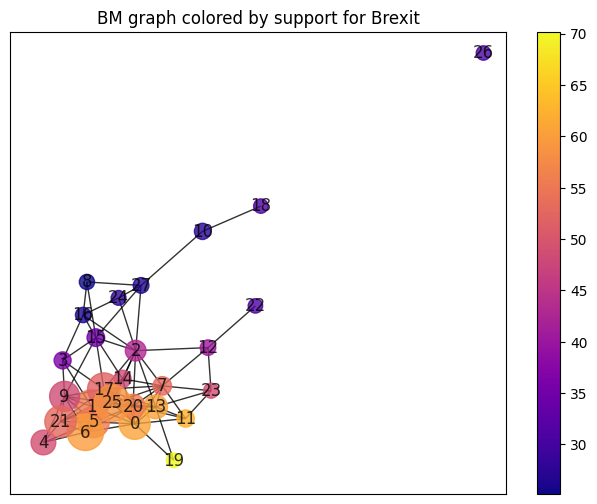

In [7]:
plt.figure(figsize=(8, 6))
bm.add_coloring(coloring_df)
# In this case we color the graph by support for Brexit in 2016 referendum.
bm.draw_networkx(
    coloring_variable="leaveHanretty", color_palette=my_rainbow_palette, colorbar=True
)
plt.title("BM graph colored by support for Brexit")
plt.show()

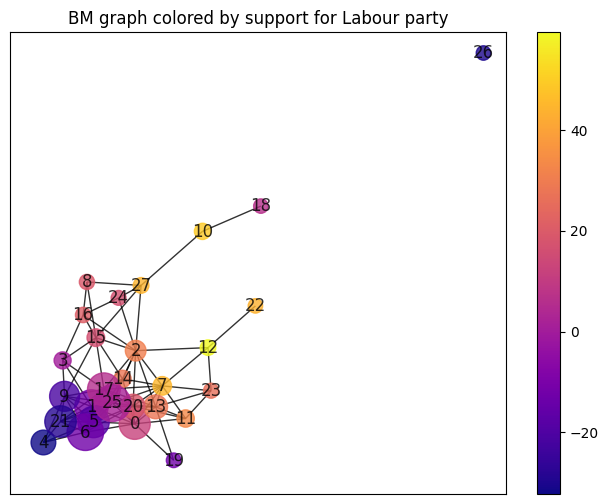

In [8]:
# In this case we color the graph by support for Labour party in 2017 election.
plt.figure(figsize=(8, 6))
bm.add_coloring(coloring_df)
# In this case we color the graph by support for Brexit in 2016 referendum.
bm.draw_networkx(
    coloring_variable="lm17", color_palette=my_rainbow_palette, colorbar=True
)
plt.title("BM graph colored by support for Labour party")
plt.show()

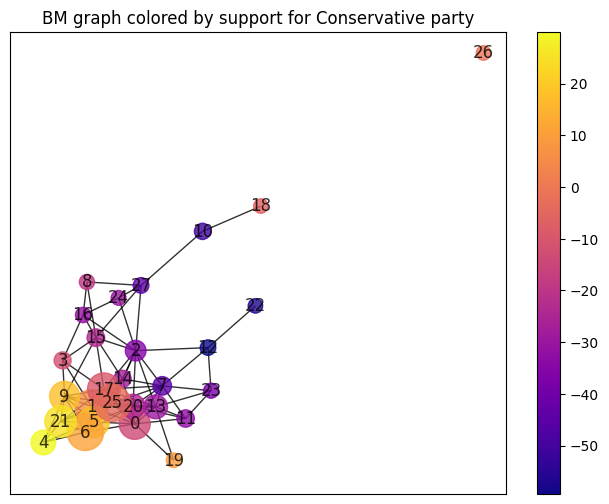

In [9]:
# In this case we color the graph by support for Conservative party in 2017 election
plt.figure(figsize=(8, 6))
bm.add_coloring(coloring_df)
# In this case we color the graph by support for Brexit in 2016 referendum.
bm.draw_networkx(
    coloring_variable="cm17", color_palette=my_rainbow_palette, colorbar=True
)
plt.title("BM graph colored by support for Conservative party")
plt.show()

# Fetching the underlying data

In [10]:
ball_id = 27

# get details about the data covered by a given ball number (here 27)
dfs = bm.ball_data(ball_numbers=ball_id)
dfs[ball_id].head()

,c11HouseOutright,c11HouseMortgage,c11HouseholdOnePerson,c11HouseholdMarried,c11CarsNone,c11CarsOne,c11CarsTwo,c11NSSECLowerManager,c11QualNone,c11QualLevel4,c11HealthVeryGood,c11HealthGood,c11DeprivedNone,c11Deprived1
0,14.692964,26.371544,32.451985,23.122470,49.218414,40.065455,8.931186,28.040157,14.166839,47.597598,53.348953,31.806010,44.343726,31.058910
1,11.357263,20.930584,34.598128,23.404806,49.754088,40.428836,8.283360,22.357155,17.835816,40.024112,52.277409,31.927229,38.299754,33.720178
2,13.885969,16.861943,38.412431,19.577974,59.204113,34.341253,5.627019,26.699414,13.628897,47.458755,54.381068,30.292804,37.531298,35.463216
3,19.596853,18.573559,38.345246,23.076396,53.211292,37.073413,7.927530,29.294016,11.505612,54.012714,54.905415,30.527198,42.446993,33.871548
4,18.905116,26.629605,32.771130,25.666635,45.336851,41.982474,10.549326,29.909421,12.403615,51.955002,53.253666,32.110209,44.347498,32.430039


In [11]:
list_of_ball_ids = [27, 10]

# get details about the data covered by a given ball number (here 27)
dfs = bm.ball_data(ball_numbers=list_of_ball_ids)

# print the results for either a ball number 10 or 27
dfs[10].head()

,c11HouseOutright,c11HouseMortgage,c11HouseholdOnePerson,c11HouseholdMarried,c11CarsNone,c11CarsOne,c11CarsTwo,c11NSSECLowerManager,c11QualNone,c11QualLevel4,c11HealthVeryGood,c11HealthGood,c11DeprivedNone,c11Deprived1
0,7.700125,16.703265,35.676823,17.329365,63.551894,31.328603,4.315555,22.427198,15.785206,44.503882,54.207173,31.077599,34.749469,37.642234
1,8.351513,15.015435,34.309529,20.135830,66.700967,28.923647,3.801194,21.736022,20.829048,39.596250,49.767453,32.627582,30.442478,35.715168
2,8.465629,18.596206,32.443642,19.253056,59.072869,34.471742,5.584220,21.650513,18.293499,37.604488,51.822305,31.681919,32.485315,34.985712
3,10.179006,16.877993,33.742247,21.510167,62.799325,32.187721,4.337756,25.686997,20.003017,42.139086,53.801275,29.947046,32.886472,35.214336
4,6.722242,13.761775,36.348587,15.955224,66.465650,29.084388,3.781877,23.681949,19.101452,41.469021,50.372143,31.594973,30.032320,36.208663


In [12]:
# asking for data from nonexisting ball
list_of_ball_ids = [60]

# get details about the data covered by a given ball number (here 27)
dfs = bm.ball_data(ball_numbers=list_of_ball_ids)

Exception: Incorrect ball number(s). The ball numbers should be in the range [0, 27]

In [13]:
# fetching indices of the points from a certain ball pointing to the original dataset
lists = bm.ball_data_index(ball_numbers=[27, 10])
lists[27]

[195, 265, 273, 277, 305, 321, 349, 351, 527, 557]

In [14]:
# fetching indices of the points from a nonexisting ball
lists = bm.ball_data_index(ball_numbers=[27, 10, 60])

Exception: Incorrect ball number(s). The ball numbers should be in the range [0, 27]

In [15]:
# get the dataframe with all the centers of the balls
bm.landmarks_data.head()

,c11HouseOutright,c11HouseMortgage,c11HouseholdOnePerson,c11HouseholdMarried,c11CarsNone,c11CarsOne,c11CarsTwo,c11NSSECLowerManager,c11QualNone,c11QualLevel4,c11HealthVeryGood,c11HealthGood,c11DeprivedNone,c11Deprived1
0,34.638944,32.195737,30.358080,32.636774,27.893871,43.743218,22.205888,16.463841,32.942170,16.616164,44.552644,28.279376,32.230740,29.679023
1,41.254738,28.490208,34.653348,29.650979,22.386292,44.484365,24.944725,21.820834,23.692828,27.132143,46.592218,32.620757,40.875711,34.258528
2,18.665396,25.953521,39.251911,23.759503,39.594118,42.959867,14.550259,15.823809,22.458717,28.961033,52.196600,31.834146,40.373828,33.189665
3,28.550115,33.383064,39.461549,29.058728,27.790587,45.707310,21.562910,22.449853,17.018925,40.295621,56.591950,30.467719,51.914644,30.473801
4,34.804265,40.030155,24.446718,46.327608,10.196005,38.818588,38.067417,24.474687,18.127272,33.289639,58.727511,30.310762,53.012762,31.304184


# Bokeh graphs

In [15]:
# We can plot the same graphs using Bokeh
from pyballmapper.plotting import graph_GUI
from bokeh.plotting import figure, show

bm.add_coloring(coloring_df)
my_fancy_gui = graph_GUI(bm.Graph, my_rainbow_palette)

In [16]:
# In this case we color the graph by support for Brexit in 2016 referendum.
my_fancy_gui.color_by_variable("leaveHanretty")
show(my_fancy_gui.plot)

color by variable leaveHanretty 
MIN_VALUE: 25.163, MAX_VALUE: 70.162


In [17]:
# In this case we color the graph by support for Labour party in 2017 election.
my_fancy_gui.color_by_variable("lm17")
show(my_fancy_gui.plot)

color by variable lm17 
MIN_VALUE: -32.208, MAX_VALUE: 59.374


In [18]:
# In this case we color the graph by support for Conservative party in 2017 election
my_fancy_gui.color_by_variable("cm17")
show(my_fancy_gui.plot)

color by variable cm17 
MIN_VALUE: -59.374, MAX_VALUE: 29.965


In [19]:
# We may want to see why there is a node 20 so different from others supporting Tories
one = [20]
two = [6, 7, 10]

one_points = np.unique(
    np.concatenate([bm.points_covered_by_landmarks[node] for node in one])
)

two_points = np.unique(
    np.concatenate([bm.points_covered_by_landmarks[node] for node in two])
)

In [20]:
# absolute difference of the averages, divided by the average in the whole dataset
(
    abs(db104.iloc[one_points].mean() - db104.iloc[two_points].mean()) / db104.mean()
).sort_values(ascending=False)

c11CarsNone              0.238806
c11QualNone              0.219504
c11QualLevel4            0.197607
c11HouseOutright         0.166643
c11CarsTwo               0.160250
c11NSSECLowerManager     0.114267
c11DeprivedNone          0.107991
c11HouseMortgage         0.063566
c11HouseholdOnePerson    0.062853
c11HealthGood            0.061678
c11HouseholdMarried      0.042710
c11Deprived1             0.028851
c11CarsOne               0.008205
c11HealthVeryGood        0.003948
dtype: float64

We see that the coordinates 9, 10 and 13 makes much difference. To find out what they are, we should look at the list of variables: \

1 - dt1$c11HouseOutright, \
2 - dt1$c11HouseMortgage\
3 - dt1$c11HouseholdOnePerson \
4 - dt1$c11HouseholdMarried\
5 - dt1$c11CarsNone\
6 - dt1$c11CarsOne\
7 - dt1$c11CarsTwo\
8 - dt1$c11NSSECLowerManager\
9 - dt1$c11QualNone\
10 - dt1$c11QualLevel4\
11 - dt1$c11HealthVeryGood\
12 - dt1$c11HealthGood\
13 - dt1$c11DeprivedNone\
14 - dt1$c11Deprived1\

Therefore we have no (9) or lowest (10) level of qualification and deprivation of the area. One can bring this analysis forward, and find the regions responsible for that, but we will not do it here.